In [2]:
import pandas as pd

df = pd.read_csv('./data/StudentPerformanceFactors.csv')
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.columns.tolist()

In [ ]:
df.dtypes

In [4]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [5]:
# Fill missing categorical values with the most frequent value in that column
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

# Confirm all missing values are fixed
df.isnull().sum()

C:\Users\visha\AppData\Local\Temp\ipykernel_31720\1844860241.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
C:\Users\visha\AppData\Local\Temp\ipykernel_31720\1844860241.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
# Correct way to fill missing values in newer pandas versions
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

# Confirm all missing values are fixed
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

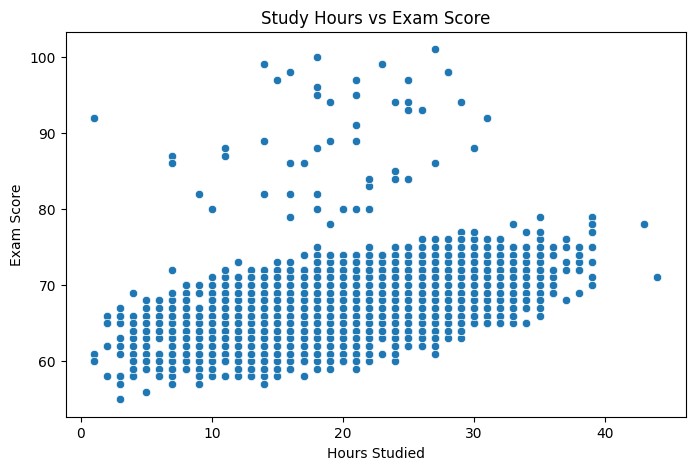

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
plt.title('Study Hours vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

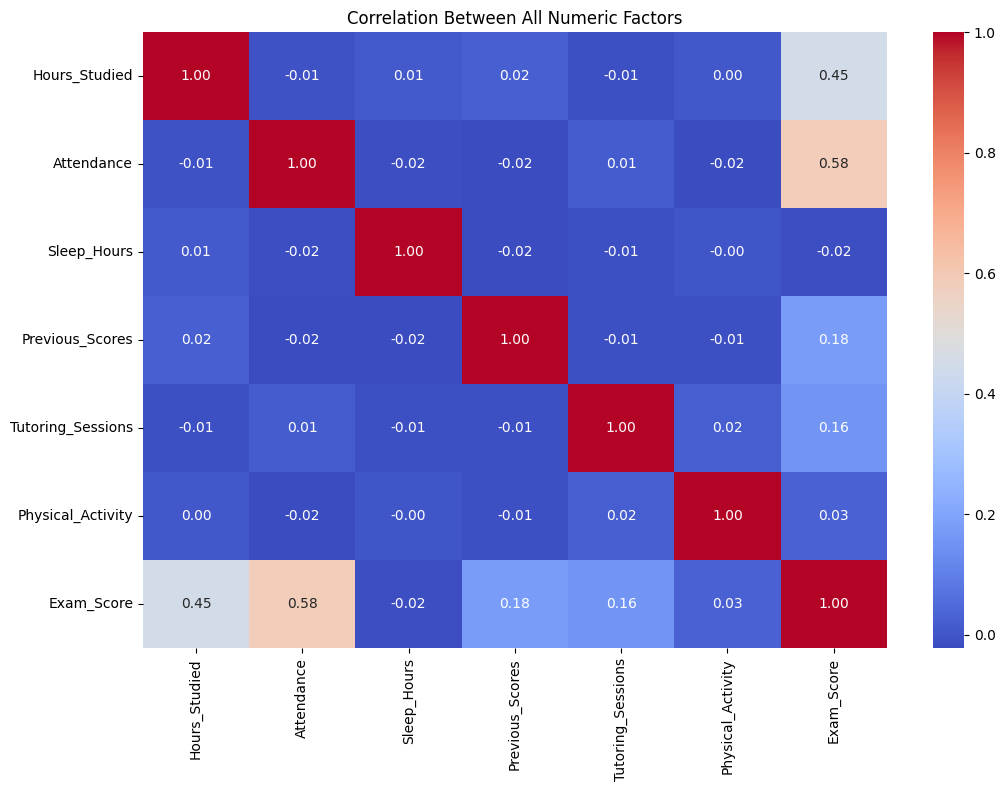

In [8]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between All Numeric Factors')
plt.show()

In [9]:
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [11]:
categorical_columns = X.select_dtypes(include='str').columns.tolist()
print("Categorical columns:", categorical_columns)

# Convert each categorical column into numbers
X = pd.get_dummies(X, columns=categorical_columns)

print("New shape after encoding:", X.shape)

Categorical columns: []
New shape after encoding: (6607, 40)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5285
Testing samples: 1322


In [13]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (5285, 40)
Testing samples: (1322, 40)


In [14]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training complete! ✅")

Model training complete! ✅


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print evaluation report
print("=" * 40)
print("       MODEL EVALUATION REPORT")
print("=" * 40)
print(f"Model Used       : Linear Regression")
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Total Features   : {X_train.shape[1]}")
print("-" * 40)
print(f"MAE  (Avg Error)         : {mae:.2f} points")
print(f"RMSE (Penalized Error)   : {rmse:.2f} points")
print(f"R²   (Accuracy)          : {r2:.4f} ({r2*100:.2f}%)")
print("=" * 40)


       MODEL EVALUATION REPORT
Model Used       : Linear Regression
Training Samples : 5285
Testing Samples  : 1322
Total Features   : 40
----------------------------------------
MAE  (Avg Error)         : 0.45 points
RMSE (Penalized Error)   : 1.80 points
R²   (Accuracy)          : 0.7696 (76.96%)


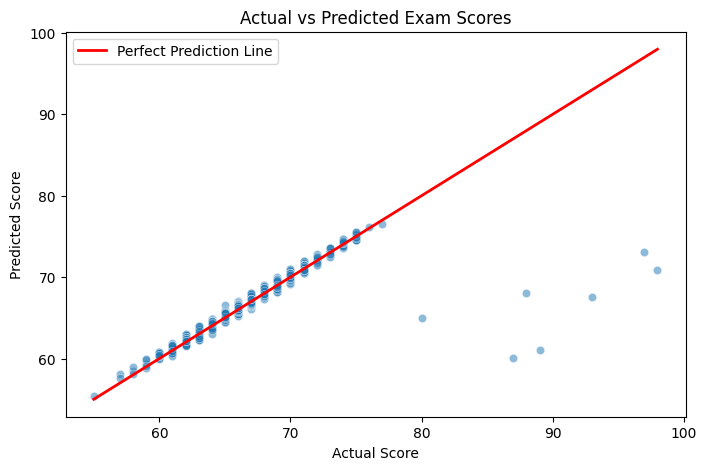

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.title('Actual vs Predicted Exam Scores')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.legend()
plt.show()


In [17]:
import joblib

joblib.dump(model, '../model/score_predictor.pkl')
print("Model saved successfully! ✅")

FileNotFoundError: [Errno 2] No such file or directory: '../model/score_predictor.pkl'

In [18]:
import joblib

joblib.dump(model, './model/score_predictor.pkl')
print("Model saved successfully! ✅")

Model saved successfully! ✅


In [19]:
import numpy as np

def predict_student_score(hours_studied, attendance, sleep_hours, 
                          previous_scores, tutoring_sessions, physical_activity):
    
    # Create a blank template with all 40 columns set to 0
    input_data = pd.DataFrame(columns=X.columns)
    input_data.loc[0] = 0

    # Fill in the numeric values
    input_data['Hours_Studied'] = hours_studied
    input_data['Attendance'] = attendance
    input_data['Sleep_Hours'] = sleep_hours
    input_data['Previous_Scores'] = previous_scores
    input_data['Tutoring_Sessions'] = tutoring_sessions
    input_data['Physical_Activity'] = physical_activity

    # Make prediction
    predicted_score = model.predict(input_data)[0]
    
    print("=" * 40)
    print("       STUDENT SCORE PREDICTION")
    print("=" * 40)
    print(f"Hours Studied       : {hours_studied}")
    print(f"Attendance          : {attendance}%")
    print(f"Sleep Hours         : {sleep_hours}")
    print(f"Previous Scores     : {previous_scores}")
    print(f"Tutoring Sessions   : {tutoring_sessions}")
    print(f"Physical Activity   : {physical_activity}")
    print("-" * 40)
    print(f"Predicted Exam Score: {predicted_score:.1f} / 100")
    print("=" * 40)

In [20]:
predict_student_score(
    hours_studied=7,
    attendance=85,
    sleep_hours=7,
    previous_scores=75,
    tutoring_sessions=2,
    physical_activity=3
)

       STUDENT SCORE PREDICTION
Hours Studied       : 7
Attendance          : 85%
Sleep Hours         : 7
Previous Scores     : 75
Tutoring Sessions   : 2
Physical Activity   : 3
----------------------------------------
Predicted Exam Score: 63.6 / 100


In [21]:
predict_student_score(
    hours_studied=2,
    attendance=55,
    sleep_hours=5,
    previous_scores=50,
    tutoring_sessions=0,
    physical_activity=1
)


       STUDENT SCORE PREDICTION
Hours Studied       : 2
Attendance          : 55%
Sleep Hours         : 5
Previous Scores     : 50
Tutoring Sessions   : 0
Physical Activity   : 1
----------------------------------------
Predicted Exam Score: 53.6 / 100


In [22]:
predict_student_score(
    hours_studied=5,
    attendance=75,
    sleep_hours=7,
    previous_scores=65,
    tutoring_sessions=1,
    physical_activity=3
)

       STUDENT SCORE PREDICTION
Hours Studied       : 5
Attendance          : 75%
Sleep Hours         : 7
Previous Scores     : 65
Tutoring Sessions   : 1
Physical Activity   : 3
----------------------------------------
Predicted Exam Score: 60.1 / 100


In [23]:
predict_student_score(
    hours_studied=10,
    attendance=95,
    sleep_hours=8,
    previous_scores=90,
    tutoring_sessions=4,
    physical_activity=5
)

       STUDENT SCORE PREDICTION
Hours Studied       : 10
Attendance          : 95%
Sleep Hours         : 8
Previous Scores     : 90
Tutoring Sessions   : 4
Physical Activity   : 5
----------------------------------------
Predicted Exam Score: 68.6 / 100
